In [1284]:
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [1285]:
BASE_PATH: Path = Path.cwd()
RANDOM_SEED: float = 0

sns.set_theme(style="darkgrid", palette="dark")

In [1286]:
df_raw: pl.DataFrame = pl.read_csv(
    BASE_PATH / 'data' / 'raw' / 'raw_mock_sales_data.csv',
    schema_overrides = {
        'SaleDate': pl.String,
        'ProductID': pl.String,
        'ASP': pl.String,
        'QT': pl.String,
    }
)

In [1287]:
df_raw.head(5)

SaleDate,ProductID,ASP,QT
str,str,str,str
"""2024-02-11""","""P003""","""46.11""","""3.0"""
"""2025-04-20""","""P007""","""50.76""","""3.0"""
"""07/04/2025""","""P001""","""122.77""","""5.0"""
"""2020-02-14""","""P004""","""98.75""","""6.0"""
"""2022-06-28""","""P010""","""51.81""","""3.0"""


In [1288]:
df_raw.describe()

statistic,SaleDate,ProductID,ASP,QT
str,str,str,str,str
"""count""","""200174""","""200151""","""200175""","""200174"""
"""null_count""","""126""","""149""","""125""","""126"""
"""mean""",null,null,null,null
"""std""",null,null,null,null
"""min""","""01-03-2024""",""" P001 ""","""$10.00""","""-1.0"""
"""25%""",null,null,null,null
"""50%""",null,null,null,null
"""75%""",null,null,null,null
"""max""","""31/05/2026""","""product_1""","""9980.0""","""99.0"""


In [1289]:
def get_inconsistencies(df: pl.DataFrame, column: str, store: bool) -> pl.DataFrame | None:
    inconsistencies_df: pl.DataFrame = pl.DataFrame()

    if column == 'SaleDate':
        inconsistencies_df: pl.DataFrame = df.with_columns(
            pl.col(column).str.to_date(format='%Y-%m-%d', strict=False).is_null().alias('inconsistent'),
        ).filter(
            pl.col('inconsistent') == True
        )

    if column == 'ProductID':
        inconsistencies_df: pl.DataFrame = df.with_columns(
            ~pl.col(column).str.contains(r"^P\d{3}$").alias('inconsistent'),
        ).filter(
            pl.col('inconsistent') == True
        )

    if column in ['QT', 'ASP']:
        inconsistencies_df: pl.DataFrame = df.with_columns(
            (
                (pl.col(column).cast(pl.Float64, strict=False) <= 0) |
                (pl.col(column).cast(pl.Float64, strict=False).is_null())
            ).alias('inconsistent'),
        ).filter(
            pl.col('inconsistent') == True
        )

    inconsistencies_path: Path = BASE_PATH / 'exploratory_output' / 'inconsistencies'

    if len(inconsistencies_df) > 0 and store:
        inconsistencies_df.write_csv(
            inconsistencies_path / f'inconsistencies_{column}.csv',
            separator=';'
        )

        return inconsistencies_df
    return None

In [1290]:
for column in df_raw.columns:
    inconsistencies_df: pl.DataFrame = get_inconsistencies(df_raw, column, True)

    size: int | None = len(inconsistencies_df) if inconsistencies_df is not None else 0
    print(f'Column {column} inconsistencies: {size}')

Column SaleDate inconsistencies: 526
Column ProductID inconsistencies: 299
Column ASP inconsistencies: 575
Column QT inconsistencies: 576


In [1291]:
allowed_date_formats: list = [
    "%Y-%m-%d",    # 2025-12-01
    "%d/%m/%Y",    # 01/12/2025
    "%m-%d-%Y",    # 12-01-2026
    "%Y%m%d",      # 20251201
    "%d-%b-%Y",    # 01-Dec-2025
]

df_cleaned = (df_raw
    .filter(
        ~pl.col('ProductID').is_in(['UNKNOWN', '#REF!', 'N/A', 'P00O', 'null']),
        pl.col('ProductID') != 'P999',
        pl.col('ProductID').is_not_null(),
        pl.col('SaleDate').is_not_null(),
    )

    .with_columns(
        pl.coalesce([
            pl.col('SaleDate').str.to_date(format=date_format, strict=False)
            for date_format in allowed_date_formats
        ]).alias('SaleDate')
    )

    .with_columns(
        pl.col('ProductID').str.strip_chars().alias('ProductID')
    )

    .with_columns(
        pl.when(
            pl.col('ProductID').str.starts_with('p')
        ).then(
            pl.col('ProductID').str.replace('p', 'P')
        ).otherwise('ProductID').alias('ProductID')
    )

    .with_columns(
        pl.when(
            pl.col('ProductID').str.starts_with('Product')
        ).then(
            pl.col('ProductID').str.replace('Product', 'P')
        ).otherwise('ProductID').alias('ProductID')
    )

    .with_columns(
        pl.when(
            pl.col('ProductID') == 'P_1'
        ).then(
            pl.lit('P001')
        ).otherwise('ProductID').alias('ProductID')
    )

    .with_columns(
        pl.col('ASP').str.replace('$', '', literal=True).alias('ASP')
    )

    .with_columns(
        pl.when(
            pl.col('QT').cast(pl.Float64, strict=False) < 0
        ).then(
            - pl.col('QT').cast(pl.Float64, strict=False)
        ).otherwise('QT').alias('QT'),
        pl.when(
            pl.col('ASP').cast(pl.Float64, strict=False) < 0
        ).then(
            - pl.col('ASP').cast(pl.Float64, strict=False)
        ).otherwise('ASP').alias('ASP'),
    )

    .with_columns(
        pl.col('QT').cast(pl.Float64),
        pl.col('ASP').cast(pl.Float64)
    )
)


df_cleaned = (
    df_cleaned
    .sort(["ProductID", "SaleDate"])

    .with_columns(
        pl.col("ASP").forward_fill().over("ProductID"),
    )

    .with_columns(
        pl.col("ASP").backward_fill().over("ProductID"),
    )

    .with_columns(
        pl.col("QT").interpolate("linear").over("ProductID"),
    )

    .with_columns(
        pl.col("QT").fill_null(pl.col("QT").median().over("ProductID")),
    )
)

df_cleaned = df_cleaned.filter(
    pl.col('SaleDate') < dt.date(dt.date.today().year, dt.date.today().month, 1)
)

df_cleaned_test: pl.DataFrame = df_cleaned
for column in df_cleaned.columns:
    df_cleaned_test = df_cleaned_test.with_columns(
        pl.col(column).cast(pl.String)
    )

In [1292]:
for column in df_cleaned_test.columns:
    inconsistencies_df: pl.DataFrame = get_inconsistencies(df_cleaned_test, column, False)

    size: int = len(inconsistencies_df) if inconsistencies_df is not None else 0
    print(f'Column {column} inconsistencies: {size}')

Column SaleDate inconsistencies: 0
Column ProductID inconsistencies: 0
Column ASP inconsistencies: 0
Column QT inconsistencies: 0


In [1293]:
df_cleaned

SaleDate,ProductID,ASP,QT
date,str,f64,f64
2020-01-01,"""P001""",96.58,21.0
2020-01-01,"""P001""",97.77,13.0
2020-01-01,"""P001""",97.11,12.0
2020-01-01,"""P001""",97.23,12.0
2020-01-01,"""P001""",97.26,16.0
…,…,…,…
2026-06-17,"""P010""",47.72,14.0
2026-06-17,"""P010""",47.43,30.0
2026-06-17,"""P010""",47.68,19.0


In [1294]:
df_cleaned.describe()

statistic,SaleDate,ProductID,ASP,QT
str,str,str,f64,f64
"""count""","""199756""","""199756""",199756.0,199756.0
"""null_count""","""0""","""0""",0.0,0.0
"""mean""","""2023-04-30 17:32:35.097218""",null,69.080843,12.292229
"""std""",null,null,148.065141,125.783467
"""min""","""2020-01-01""","""P001""",0.09,0.0
"""25%""","""2021-09-27""",null,45.73,4.0
"""50%""","""2023-05-19""",null,61.64,8.0
"""75%""","""2024-12-10""",null,98.37,14.0
"""max""","""2026-06-17""","""P010""",12816.0,15500.0


In [1295]:
df_cleaned = df_cleaned.filter(
    pl.col('SaleDate') < dt.date(2026, 6, 1)
)

In [1296]:
df_cleaned = df_cleaned.rename({
    'SaleDate': 'ds_full',
    'ProductID': 'SKU'
})

In [1297]:
def line_plot(df: pl.DataFrame, x: str, y: str, title: str, hue: str | None = None) -> None:
    fig, ax = plt.subplots(figsize=(18, 6))
    fig.suptitle(title)
    sns.lineplot(data=df, x=x, y=y, hue=hue, ax=ax)
    plt.show()

In [1298]:
for target in ['QT', 'ASP']:
    window: int = 31

    df_cleaned = (
        df_cleaned
        .sort(['SKU', 'ds_full'])
        .with_columns(
            pl.col(target).rolling_median(window_size=window, min_samples=1).over('SKU').alias(f'{target}_rolling_median'),
        )

        .with_columns(
            (pl.col(target) - pl.col(f'{target}_rolling_median')).abs().rolling_median(window_size=window, min_samples=1).over('SKU').alias(f'{target}_rolling_mad')
        )

        .with_columns(
            (((pl.col(target) - pl.col(f'{target}_rolling_median')) / (pl.col(f'{target}_rolling_mad') * 1.4826)).abs() > 3).alias(f'{target}_outlier'))
    )

df_full: pl.DataFrame = df_cleaned

df_filtered = df_cleaned.filter(~pl.col('ASP_outlier') & ~pl.col('QT_outlier'))

In [1299]:
df_filtered

ds_full,SKU,ASP,QT,QT_rolling_median,QT_rolling_mad,QT_outlier,ASP_rolling_median,ASP_rolling_mad,ASP_outlier
date,str,f64,f64,f64,f64,bool,f64,f64,bool
2020-01-01,"""P001""",97.77,13.0,17.0,2.0,false,97.175,0.2975,false
2020-01-01,"""P001""",97.23,12.0,12.5,0.75,false,97.17,0.03,false
2020-01-01,"""P001""",97.26,16.0,13.0,1.0,false,97.23,0.03,false
2020-01-02,"""P001""",96.96,8.0,12.5,2.75,false,97.17,0.135,false
2020-01-02,"""P001""",97.3,6.0,12.0,3.0,false,97.23,0.07,false
…,…,…,…,…,…,…,…,…,…
2026-05-31,"""P010""",48.88,13.0,8.0,6.0,false,48.68,0.33,false
2026-05-31,"""P010""",49.23,9.0,9.0,6.0,false,48.68,0.33,false
2026-05-31,"""P010""",49.19,7.0,9.0,6.0,false,48.68,0.33,false


In [1300]:
def featurize(df: pl.DataFrame, target: str) -> pl.DataFrame:
    return df.with_columns(
        pl.col('ds_full').dt.year().alias('Y'),
        pl.col('ds_full').dt.month().alias('M'),
        pl.col('ds_full').dt.strftime("%Y/%m").alias('YearMonth')
    ).group_by([
        'SKU',
        'YearMonth',
        'Y',
        'M',
    ]).agg([
        pl.col('QT').sum().alias('QT'),
        pl.col('ASP').mean().alias('ASP'),
    ]).with_columns(
        pl.date(pl.col('Y'), pl.col('M'), 1).alias('ds')
    ).sort(
        by=['ds', 'SKU'],
        descending=False
    ).select([
        'SKU',
        'ds',
        'Y',
        'M',
        target
    ]).rename({target: 'y'})

In [1301]:
df_QT: pl.DataFrame = featurize(df=df_filtered, target='QT')
df_ASP: pl.DataFrame = featurize(df=df_filtered, target='ASP')

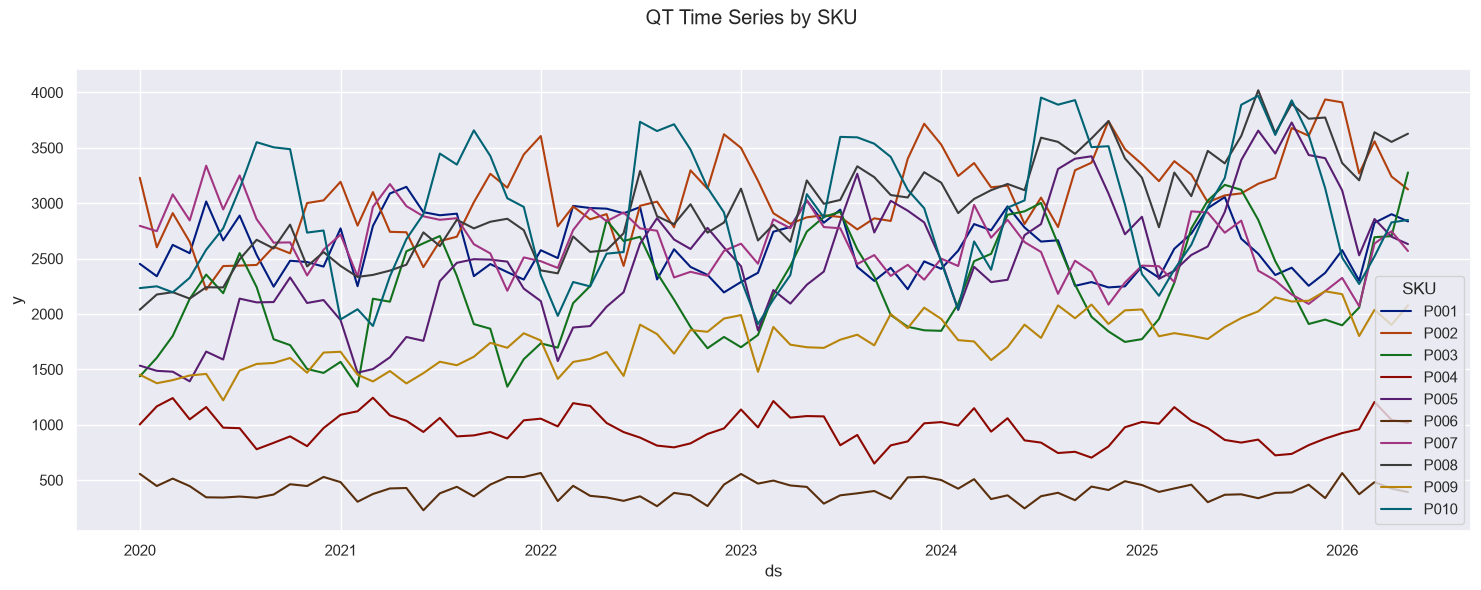

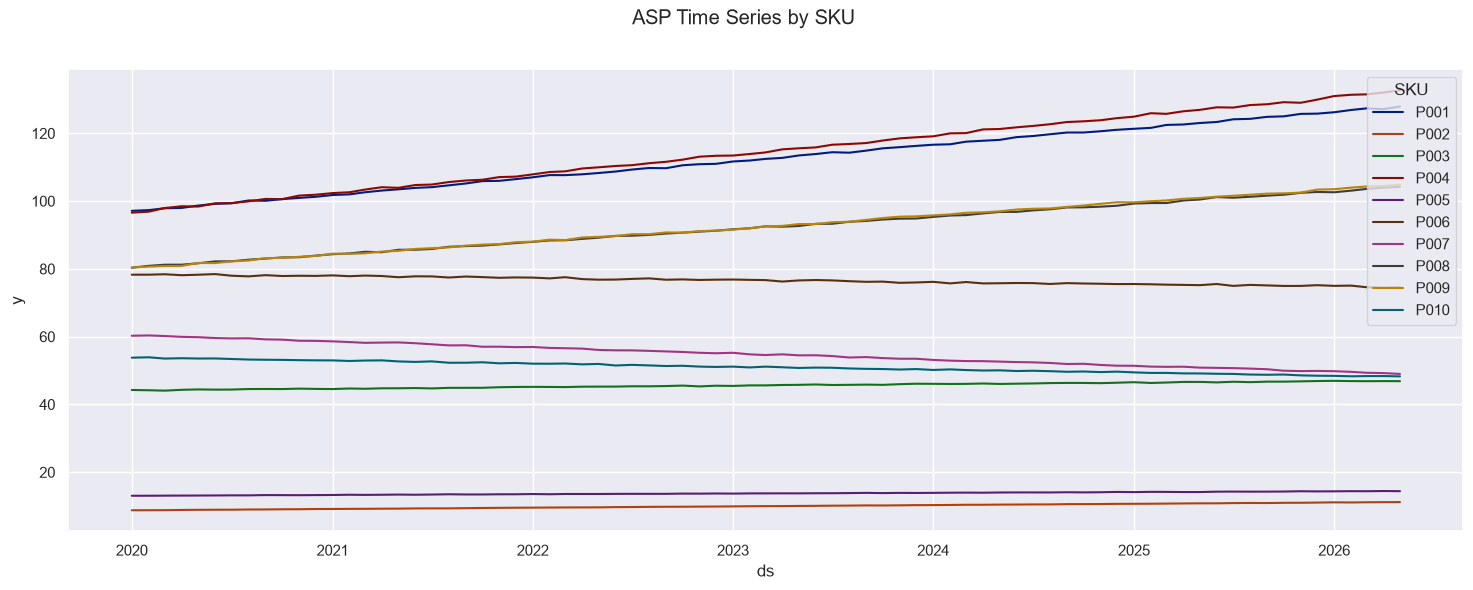

In [1302]:
line_plot(df_QT, x='ds', y='y', hue='SKU', title='QT Time Series by SKU')
line_plot(df_ASP, x='ds', y='y', hue='SKU', title='ASP Time Series by SKU')

In [1303]:
def add_noise(noiseless_df: pl.DataFrame, noise_multiplier: float) -> pl.DataFrame:
    noise: np.ndarray = np.random.default_rng(RANDOM_SEED).normal(1.0, noise_multiplier, len(noiseless_df))

    return noiseless_df.with_columns(
        (pl.col("y") * pl.Series("noise", noise)).round(2).alias("y")
    )

In [1304]:
df_QT_P001_noiseless: pl.DataFrame = df_QT.filter(pl.col('SKU') == 'P001')
df_QT_P001_with_noise: pl.DataFram = add_noise(df_QT_P001_noiseless, noise_multiplier=0.05)

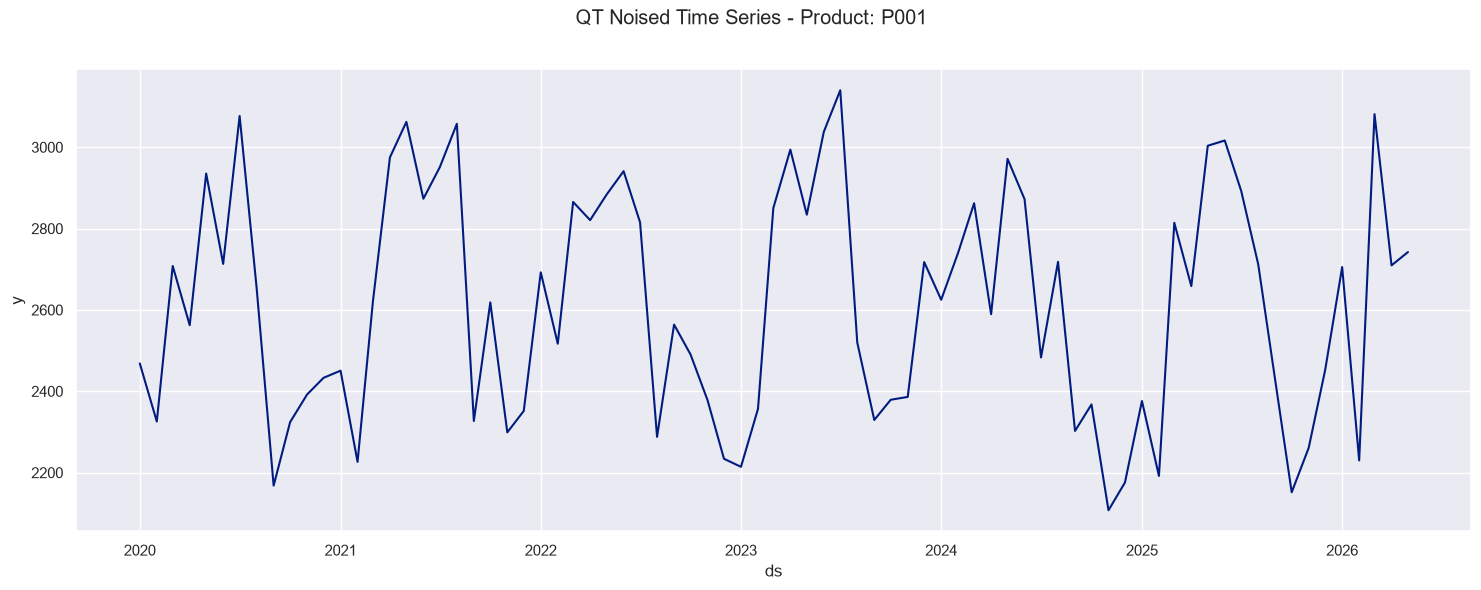

In [1305]:
line_plot(df_QT_P001_with_noise, x='ds', y='y', title='QT Noised Time Series - Product: P001')

In [1306]:
df_QT_P001_with_noise: pd.DataFrame = df_QT_P001_with_noise.to_pandas()
df_QT_P001_with_noise['ds'] = pd.to_datetime(df_QT_P001_with_noise['ds'])

In [1307]:
from statsmodels.tsa.seasonal import STL, DecomposeResult


def components_plot(df: pd.DataFrame, product: str, target: str) -> None:
    components_colors: dict[str, str] = {
        'Observed': 'grey',
        'Trend': 'blue',
        'Seasonality': 'red',
        'Residual': 'yellow',
    }

    fig, axes = plt.subplots(
        figsize = (22, 4),
        nrows = 1,
        ncols = 4,
    )

    fig.suptitle(f'{target} STL Decomposition - Product: {product}', fontsize=16, fontweight='bold')

    product_series: pd.Series = (
        df
        .set_index('ds')['y']
        .asfreq('MS')
    )
    stl: STL = STL(product_series, period=12, robust=True)
    result: DecomposeResult = stl.fit()

    components: dict[str, pd.Series] = {
        'Observed': product_series,
        'Trend': result.trend,
        'Seasonality': result.seasonal,
        'Residual': result.resid
    }

    for col_idx, (component_name, component_series) in enumerate(components.items()):
        axes[col_idx].set_title(
            component_name,
            fontsize = 14,
            fontweight = 'bold',
        )
        ax = axes[col_idx]

        if component_name in ('Seasonality', 'Residual'):
            ax.axhline(0, color='grey', linewidth=1, linestyle='--', alpha=0.6)

        if component_name == 'Residual':
            sns.scatterplot(
                x = component_series.index,
                y = component_series.values,
                ax = ax,
                color = components_colors[component_name],
            )
        else:
            sns.lineplot(
                x = component_series.index,
                y = component_series.values,
                ax = ax,
                color = components_colors[component_name],
            )

        ax.tick_params(axis='y', labelsize=9, left=True, labelleft=True)

        for spine in ax.spines.values():
                spine.set_linewidth(0.8)
                spine.set_color('grey')

    plt.tight_layout()
    plt.show()

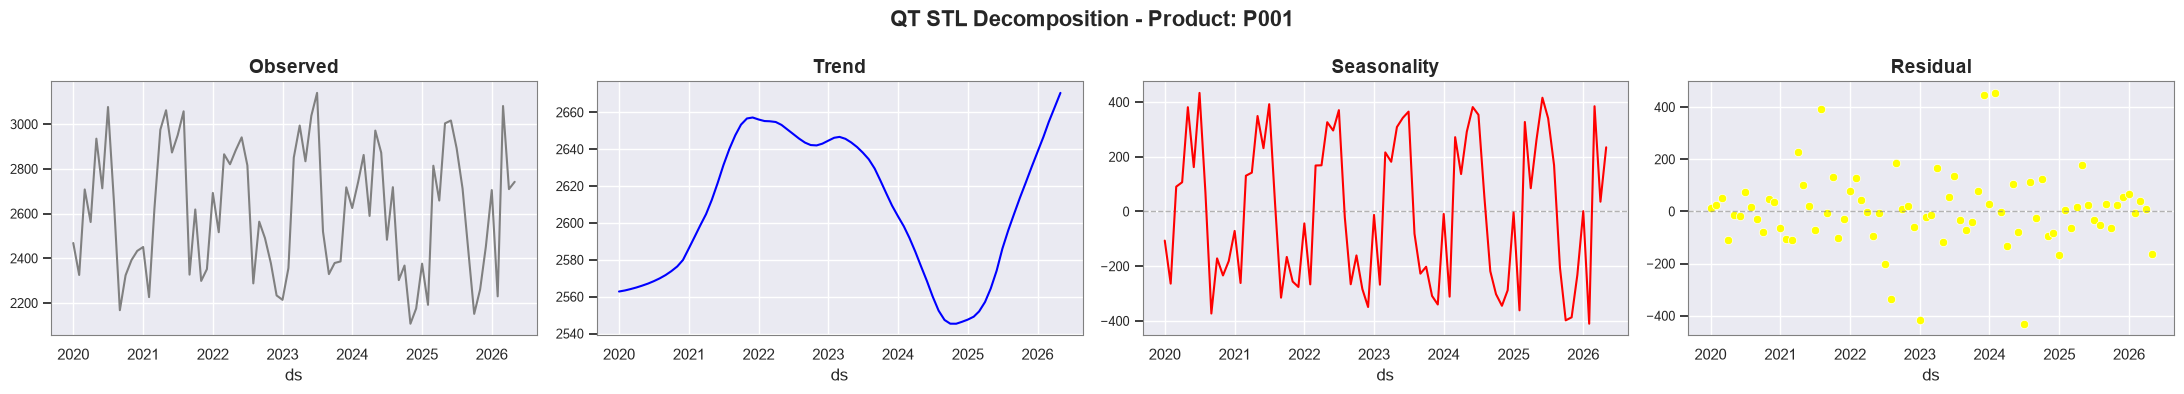

In [1308]:
components_plot(df_QT_P001_with_noise, 'P001', 'QT')

In [1309]:
def seasonal_plot(df: pd.DataFrame, product: str, target: str) -> None:
    fig, axes = plt.subplots(figsize=(22, 4))
    fig.suptitle(f'{target} Seasonal plot - Product: {product}', fontsize=16, fontweight="bold")

    sns.lineplot(
        data = df,
        x = 'month',
        y = 'y',
        hue = 'year',
        marker = 'o',
        palette='hls'
    )

    plt.tight_layout()

In [1310]:
def month_boxplot(df: pd.DataFrame, product: str, target: str) -> None:
    fig, axes = plt.subplots(figsize=(22, 4))
    fig.suptitle(f'{target} Month boxplot - Product {product}', fontsize=16, fontweight="bold")

    sns.boxplot(
        data = df,
        x = 'month',
        y = 'y'
    )

    plt.tight_layout()

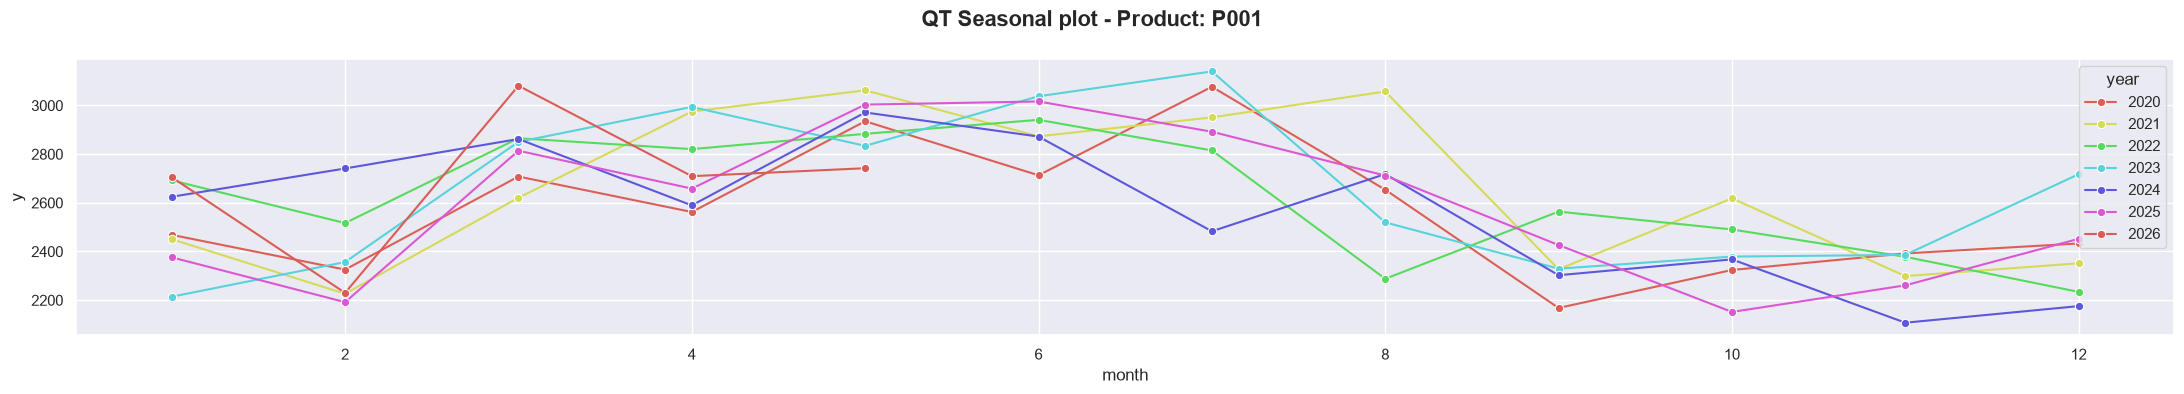

In [1311]:
df_QT_P001_seasonal: pd.DataFrame = df_QT_P001_with_noise.copy()
df_QT_P001_seasonal['month'] = df_QT_P001_seasonal['ds'].dt.month
df_QT_P001_seasonal['year'] = df_QT_P001_seasonal['ds'].dt.year

seasonal_plot(
    df_QT_P001_seasonal,
    'P001',
    'QT'
)

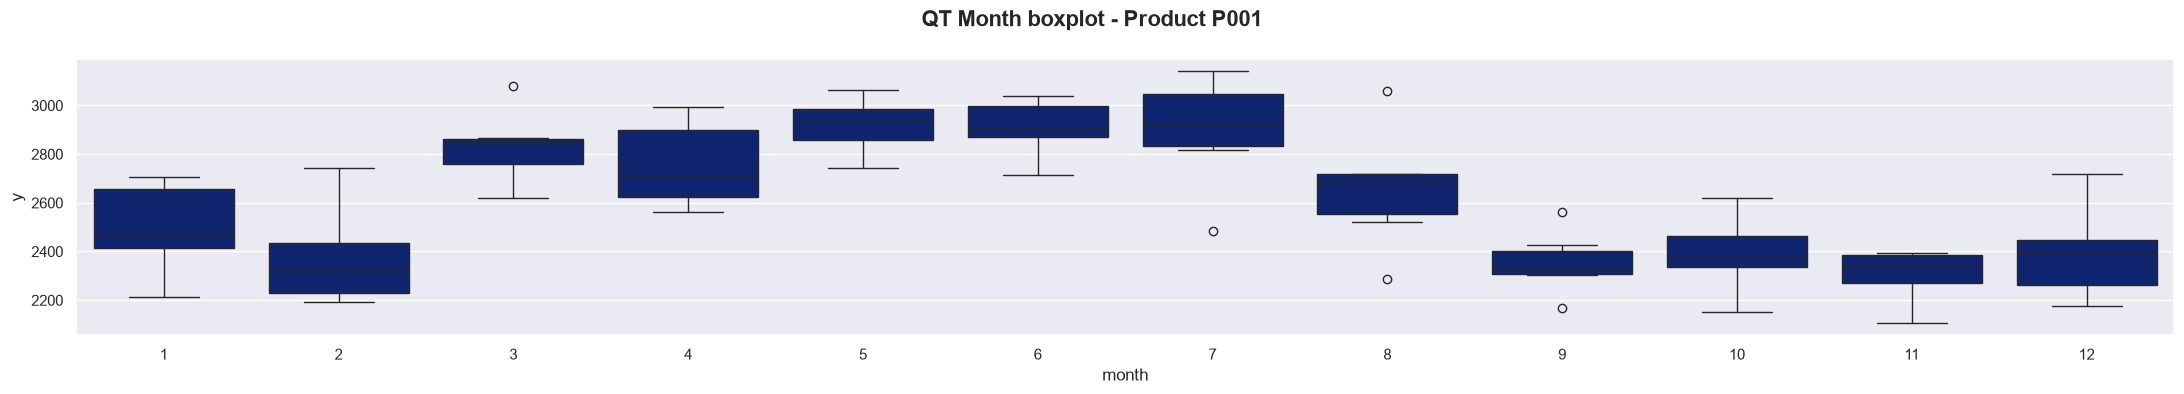

In [1312]:
month_boxplot(df_QT_P001_seasonal, 'P001', 'QT')

In [1314]:
df_QT_P001_with_noise.to_csv(BASE_PATH / 'data' / 'featurized' / 'data_P001.csv', sep=';', index=False)